<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/12_chapter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/12_chapter.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

In [1]:
import qrcode
from IPython.display import display
from PIL import Image

def generar_qr(url, version=1, box_size=4, border=4, fill_color="black", back_color="white"):
    """
    Genera y muestra un código QR para una URL dada en un Jupyter Notebook.
    
    Parámetros:
    - url: La URL para la cual generar el código QR
    - version: Tamaño del QR (1-40, donde 1 es el más pequeño)
    - box_size: Número de píxeles por cada "caja" del QR
    - border: Grosor del borde blanco alrededor del QR (en cajas)
    - fill_color: Color del código QR
    - back_color: Color de fondo del código QR
    
    Retorna:
    - Muestra el código QR directamente en el notebook
    - Retorna el objeto QR generado
    """
    # Configurar el generador de QR
    qr = qrcode.QRCode(
        version=version,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    
    # Añadir la URL al QR
    qr.add_data(url)
    qr.make(fit=True)
    
    # Crear la imagen del QR
    img = qr.make_image(fill_color=fill_color, back_color=back_color)
     
    return img


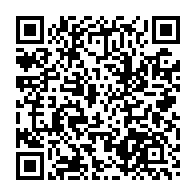

In [2]:
url = "https://colab.research.google.com/github/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/12_chapter.ipynb"
generar_qr(url) 

### [Video de apoyo a la lectura interactiva y experimental de este cuaderno]()

### [Vínculo al programa del curso de Fundamentos de Programación:](https://github.com/marco-canas/fundamentos_de_programacion/blob/main/programa/Programa_Fundamentos_Programacion.md)



## Código del curso: 314029

Un reconocimiento a mis estudiantes que han construido conmigo este saber pedagógico:

<img src = 'https://github.com/marco-canas/algebra_y_trigonometria/blob/main/7_images/5_clase_3_2025-08-12_hora_11_04.jpg?raw=true'> 



In [4]:
import pandas as pd
import numpy as np

# Cargar la lista de estudiantes desde el archivo CSV
path = 'C:/Users/marco/Documentos/docencia/groups_list/fundamentos_programacion.xlsx'
df = pd.read_excel(path)
df.index = np.arange(1, len(df) + 1)  # Cambiar el índice para que empiece en 1
df.head(6)


,Cédula,Nombre,Email,p3
1,1038648096,ACEVEDO BELEÑO SANTIAGO,sacevedo.beleno@udea.edu.co,NaN
2,1038113597,CORREA RESTREPO NICOLAS,nicolas.crestrepo@udea.edu.co,2.5
3,1038648760,MARIN VILLARREAL PABLO ALEJANDRO,pablo.marin1@udea.edu.co,NaN
4,1038647828,NIEBLES BARRERA ALEXANDER ISAAC,alexander.niebles@udea.edu.co,NaN
5,1038092717,RIVERA GUZMAN CRISTIAN,cristian.rivera2@udea.edu.co,NaN
6,1066600819,TIRADO CHAVARRIA WILFRAN DE JESUS,wilfran.tirado@udea.edu.co,NaN


# Chapter 12.  

Para este caso de uso, simularemos un análisis con un dataset clásico y muy didáctico: **el dataset de vivienda (Housing Dataset) o de clientes de un e-commerce**.




# CAPÍTULO 12: Conectando Puntos – Análisis de Datos Paso a Paso y Caso Práctico



## Objetivos de la Clase

* Aplicar de forma integrada los conocimientos previos de **Python, Pandas, NumPy y Matplotlib**.
* Seguir el flujo de trabajo real de un Científico de Datos ante un problema de negocio.
* Aprender a limpiar, transformar y extraer conclusiones de un conjunto de datos crudos.

---



## Estructura del Jupyter Notebook (Código y Contenido)

### 1. Entendiendo el Conjunto de Datos (Data Set)

> **Celda de Markdown:** Explicación del origen de los datos, el significado de cada columna (diccionario de datos) y el tipo de variables con las que vamos a trabajar (numéricas, categóricas, temporales).


In [1]:
# Celda de Código: Glosario de variables para referencia rápida durante la clase
dataset_info = {
    "id": "Identificador único del registro",
    "fecha": "Fecha de la transacción",
    "ingresos_gasto": "Ingreso mensual estimado del cliente",
    "score_credito": "Puntaje de crédito del cliente (Numérico)",
    "categoria_producto": "Categoría de producto más comprado (Categórico)",
    "satisfaccion": "Nivel de satisfacción de 1 a 5 (Ordinal)"
}
for columna, descripcion in dataset_info.items():
    print(f"🔹 {columna}: {descripcion}")


🔹 id: Identificador único del registro
🔹 fecha: Fecha de la transacción
🔹 ingresos_gasto: Ingreso mensual estimado del cliente
🔹 score_credito: Puntaje de crédito del cliente (Numérico)
🔹 categoria_producto: Categoría de producto más comprado (Categórico)
🔹 satisfaccion: Nivel de satisfacción de 1 a 5 (Ordinal)



# 2. Entendiendo la Definición del Problema (Problem Statement)

> **Celda de Markdown:** En Ciencia de Datos, nunca empezamos a programar sin un objetivo de negocio. Aquí planteamos las preguntas que queremos responder.
> * **Problema:** La empresa ha detectado una fuga de clientes en ciertos segmentos, pero no sabe exactamente qué grupo tiene el menor índice de satisfacción ni cómo influyen sus ingresos en sus decisiones de compra.
> * **Meta del Análisis:** Identificar el perfil de cliente insatisfecho y proponer un patrón visual de comportamiento mediante gráficos.
> 




### 3. Importando el Dataset en un DataFrame

> **Celda de Código:** Importación de las librerías base y carga del archivo de datos (CSV, Excel o JSON).

```python


In [ ]:
# Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración para que los gráficos se muestren inline en Jupyter
%matplotlib inline

# Carga de datos hipotética (puedes reemplazar con la ruta de tu archivo)
# url = "tu_archivo_de_datos.csv"
# df = pd.read_csv(url)

# Creamos un dataset sintético para que el cuaderno sea ejecutable de inmediato
np.random.seed(42)
data = {
    'id': range(101, 201),
    'fecha': pd.date_range(start='2025-01-01', periods=100, freq='D'),
    'ingresos_gasto': np.random.normal(3000, 800, 100),
    'score_credito': np.random.randint(300, 850, 100),
    'categoria_producto': np.random.choice(['Electrónica', 'Moda', 'Hogar', 'Deportes'], 100),
    'satisfaccion': np.random.choice([1, 2, 3, 4, 5, np.nan], 100, p=[0.1, 0.1, 0.2, 0.3, 0.2, 0.1]) # Incluye nulos
}
df = pd.DataFrame(data)

# Visualización de las primeras filas
print("Dataset cargado con éxito. Vista previa:")
df.head()



# 4. Explorando, Seleccionando, Limpiando y Preparando los Datos (EDA)

> **Celda de Markdown:** Esta es la fase donde pasamos el 70% del tiempo en Ciencia de Datos. Buscaremos datos faltantes (nulos), tipos de datos incorrectos y valores atípicos (*outliers*).

```python


# 4.1 Exploración Inicial
print("--- Información General del DataFrame ---")
df.info()

print("\n--- Estadísticas Descriptivas ---")
df.describe()

# 4.2 Identificación y Limpieza de Valores Nulos
print("\n--- Valores Faltantes por Columna ---")
print(df.isnull().sum())

# Estrategia de Limpieza: Imputar los nulos en 'satisfaccion' con la mediana
mediana_satisfaccion = df['satisfaccion'].median()
df['satisfaccion'].fillna(mediana_satisfaccion, inplace=True)
print(f"\n🔄 Valores nulos de satisfacción imputados con la mediana: {mediana_satisfaccion}")

# 4.3 Selección y Filtrado de Datos
# Supongamos que solo nos interesan clientes con ingresos mayores a 1500 para este estudio
df_filtrado = df[df['ingresos_gasto'] > 1500].copy()

# 4.4 Creación de Nuevas Variables (Feature Engineering básico)
# Clasificar el score de crédito en categorías
def categorizar_score(score):
    if score < 580: return 'Pobre'
    elif score < 670: return 'Regular'
    else: return 'Excelente'

df_filtrado['perfil_credito'] = df_filtrado['score_credito'].apply(categorizar_score)
df_filtrado.head()

```

---

### 5. Realizando el Análisis de Datos y Graficando el Resumen

> **Celda de Markdown:** Fase de conclusiones. Agrupamos los datos para responder al planteamiento del problema y creamos visualizaciones profesionales con Matplotlib.

```python
# 5.1 Agrupación de Datos (Insights)
# ¿Cuál es el ingreso promedio y la satisfacción según la categoría del producto?
resumen_categoria = df_filtrado.groupby('categoria_producto').agg(
    ingreso_promedio=('ingresos_gasto', 'mean'),
    satisfaccion_promedio=('satisfaccion', 'mean'),
    total_clientes=('id', 'count')
).reset_index()

print("--- Resumen Ejecutivo por Categoría ---")
print(resumen_categoria)

# 5.2 Visualización de Resultados
plt.figure(figsize=(12, 5))

# Gráfico 1: Relación entre Ingresos y Score de Crédito, coloreado por Satisfacción
plt.subplot(1, 2, 1)
scatter = plt.scatter(df_filtrado['ingresos_gasto'], df_filtrado['score_credito'], 
                      c=df_filtrado['satisfaccion'], cmap='viridis', alpha=0.7, edgecolors='black')
plt.title('Análisis de Clientes: Ingresos vs Score', fontsize=12)
plt.xlabel('Ingresos Mensuales ($)')
plt.ylabel('Score de Crédito')
plt.colorbar(scatter, label='Nivel de Satisfacción')
plt.grid(True, linestyle='--', alpha=0.5)

# Gráfico 2: Cantidad de clientes por perfil de crédito
plt.subplot(1, 2, 2)
perfiles = df_filtrado['perfil_credito'].value_counts()
plt.bar(perfiles.index, perfiles.values, color=['#4CAF50', '#FFC107', '#F44336'], edgecolor='black')
plt.title('Distribución de Perfiles de Crédito', fontsize=12)
plt.xlabel('Perfil')
plt.ylabel('Número de Clientes')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

```

---

## 📝 Conclusiones de la Clase y Próximos Pasos

> **Celda de Markdown Final:** > 1. **Resultados Clave:** Se logró conectar los datos crudos con respuestas de negocio. Descubrimos qué segmentos tienen peores scores o ingresos y cómo afecta a la satisfacción.
> 2. **Buenas Prácticas:** La limpieza de nulos previno sesgos en los promedios calculados.
> 3. **Reto para el Alumno:** Replica este mismo flujo cambiando el método de imputación de nulos (por ejemplo, usando la media o eliminándolos) y compara si los gráficos varían significativamente.

### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

### Continue su aprendizaje en la siguiente clase a través del siguiente [vínculo]()

## Referentes 

[Libro guía Fundamentos de programación: Data Analysis with Python: Introducing NumPy, Pandas, Matplotlib, and Essential Elements of Python Programming (English Edition) [Kindle Edition]](https://read.amazon.com/?_encoding=UTF8&asin=B0BBB56L4X&consumptionLimitReached=false&deviceAccountIds=A1032123ZASLV79K77QP&hasMultimedia=false&requiredCapabilities=EBOK_PURCHASE_ALLOWED&ref=sr_rn_kfw) Este vínculo lo debo abrir con Chrome